# Fase 2 — Clasificación supervisada Langjökull–Hvítárvatn (TDE4)

Apilado de bandas → extracción de píxeles a TSV → entrenamiento de 5 modelos (DT, SVM, ANN, KNN, NB) → matriz de confusión + overall accuracy.

**Cómo usarlo (modo equipo):**
1. Crea en tu Google Drive una carpeta, p. ej. `TDE4_Fase2/`, y dentro:
   - una subcarpeta `bandas/` con las 10 bandas Sentinel-2 (`.jp2` o `.tif`),
   - tu capa de puntos de entrenamiento (mejor `.gpkg`),
   - el polígono de la ROI (mejor `.gpkg`).

2. Ejecuta las celdas en orden. Solo hay que editar las rutas en la celda de **Configuración**.

> Tip: usa **GeoPackage (.gpkg)** para la capa de puntos y la ROI. Si usas shapefile, debes subir TODOS los archivos hermanos (`.shp`, `.shx`, `.dbf`, `.prj`), si falta alguno no abre.


## 1. Instalar dependencias

In [13]:
# pandas, numpy y matplotlib ya vienen en Colab
!pip install -q rasterio geopandas scikit-learn


## 2. Montar Google Drive

In [14]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Configuración — EDITA SOLO ESTAS RUTAS / NOMBRES

In [15]:
# Carpeta con las 10 bandas (.jp2 o .tif). Las busca recursivamente.
BANDS_DIR = "/content/drive/MyDrive/TDE4_Fase2/bandas"

# Capa de puntos de entrenamiento (10.000 puntos). .gpkg o .shp
TRAINING_LAYER = "/content/drive/MyDrive/TDE4_Fase2/puntos_entrenamiento.gpkg"
CLASS_FIELD = "clase"     # campo de texto: Agua / Vegetacion / Nieve / Suelo
CODE_FIELD  = "codigo"    # OPCIONAL: si no existe se deriva de 'clase' o de 'layer'

# Polígono de la ROI para recortar el stack
ROI_PATH = "/content/drive/MyDrive/TDE4_Fase2/ROI_Langjokull.gpkg"

# Carpeta de salida (se crea sola). Quedará en tu Drive para compartir resultados.
OUT_DIR = "/content/drive/MyDrive/TDE4_Fase2/fase2_salidas"

# --- Parámetros (normalmente no se tocan) ---
TARGET_RES   = 10.0     # resolución del stack en metros
APPLY_SCALE  = False    # True -> DN a reflectancia (DN-1000)/10000
BOA_OFFSET   = -1000.0
QUANT_VALUE  = 10000.0
RANDOM_STATE = 42
TEST_SIZE    = 0.30     # 70% train / 30% test, estratificado
DEDUP_BY_PIXEL = True   # 1 muestra por pixel de 10 m (evita filas duplicadas y fuga train/test)

# Orden canónico de bandas: (nombre_TSV, token_en_archivo, resolución_nativa)
BAND_SPEC = [
    ("B2","B02","10m"), ("B3","B03","10m"), ("B4","B04","10m"),
    ("B5","B05","20m"), ("B6","B06","20m"), ("B7","B07","20m"),
    ("B8","B08","10m"), ("B8A","B8A","20m"),
    ("B11","B11","20m"), ("B12","B12","20m"),
]
BAND_NAMES = [b[0] for b in BAND_SPEC]


## 4. Imports y utilidades

In [16]:
import os, glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
from rasterio.transform import from_origin

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, accuracy_score, cohen_kappa_score,
                             classification_report, ConfusionMatrixDisplay, f1_score)
import matplotlib.pyplot as plt


_BAND_FILES = None

def _list_band_files():
    """Lista (una vez) los raster bajo BANDS_DIR. os.walk es mas confiable que
    glob '**' sobre Google Drive montado en Colab."""
    global _BAND_FILES
    if _BAND_FILES is None:
        valid_ext = (".jp2", ".tif", ".tiff")
        _BAND_FILES = []
        for root, _, names in os.walk(BANDS_DIR):
            for n in names:
                if n.lower().endswith(valid_ext):
                    _BAND_FILES.append(os.path.join(root, n))
    return _BAND_FILES

def find_band(token, res):
    """Localiza el archivo de una banda por coincidencia de subcadena."""
    files = _list_band_files()
    t, r = token.lower(), res.lower()
    hits = [f for f in files
            if t in os.path.basename(f).lower() and r in os.path.basename(f).lower()]
    if not hits:
        hits = [f for f in files if t in os.path.basename(f).lower()]
    if hits:
        return sorted(hits)[0]
    disp = "\n        ".join(os.path.basename(f) for f in sorted(files)) or "(ninguno)"
    raise FileNotFoundError(
        f"No encontre la banda {token} ({res}) en {BANDS_DIR}.\n"
        f"      Archivos que SI ve Colab:\n        {disp}\n"
        f"      Si falta {token}, Drive quiza no termino de sincronizar: espera 1 min\n"
        f"      o reinicia el entorno y vuelve a montar el Drive.")


## 5. (Sec. 10) Recorte + apilado de las 10 bandas
Guarda `stack_langjokull_10m.tif`, que se reutiliza en la Fase 3.

In [17]:
def build_stack():
    os.makedirs(OUT_DIR, exist_ok=True)
    stack_path = os.path.join(OUT_DIR, "stack_langjokull_10m.tif")
    print("[1/4] Construyendo stack multibanda (recorte a ROI + remuestreo a 10 m)...")

    first_path = find_band(BAND_SPEC[0][1], BAND_SPEC[0][2])  # B02 @ 10 m
    with rasterio.open(first_path) as src0:
        band_crs = src0.crs

    roi = gpd.read_file(ROI_PATH).to_crs(band_crs)
    minx, miny, maxx, maxy = roi.total_bounds
    minx = np.floor(minx / TARGET_RES) * TARGET_RES
    miny = np.floor(miny / TARGET_RES) * TARGET_RES
    maxx = np.ceil(maxx / TARGET_RES) * TARGET_RES
    maxy = np.ceil(maxy / TARGET_RES) * TARGET_RES
    out_w = int(round((maxx - minx) / TARGET_RES))
    out_h = int(round((maxy - miny) / TARGET_RES))
    out_transform = from_origin(minx, maxy, TARGET_RES, TARGET_RES)
    print(f"      ROI bbox -> {out_w} x {out_h} px @ {TARGET_RES:.0f} m  (CRS {band_crs})")

    out_dtype = "float32" if APPLY_SCALE else "uint16"
    stack = np.zeros((len(BAND_SPEC), out_h, out_w), dtype=out_dtype)

    for i, (name, token, res) in enumerate(BAND_SPEC):
        path = find_band(token, res)
        with rasterio.open(path) as src:
            win = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
            arr = src.read(1, window=win, out_shape=(out_h, out_w),
                           resampling=Resampling.nearest,
                           boundless=True, fill_value=0).astype("float32")
        if APPLY_SCALE:
            arr = np.clip((arr + BOA_OFFSET) / QUANT_VALUE, 0.0, None)
            stack[i] = arr.astype("float32")
        else:
            stack[i] = arr.astype("uint16")
        print(f"      [{i+1:2d}/10] {name:<3} <- {os.path.basename(path)}")

    profile = {"driver":"GTiff","height":out_h,"width":out_w,
               "count":len(BAND_SPEC),"dtype":out_dtype,"crs":band_crs,
               "transform":out_transform,"nodata":0,"compress":"lzw"}
    with rasterio.open(stack_path, "w", **profile) as dst:
        dst.write(stack)
        for i, name in enumerate(BAND_NAMES, start=1):
            dst.set_band_description(i, name)
    print(f"      Stack guardado -> {stack_path}")
    return stack_path


## 6. (Sec. 11) Extracción de píxeles → TSV (detecta puntos/polígonos y deriva la clase)

In [18]:
import unicodedata

# Palabra clave -> (codigo, nombre canonico). Se busca como subcadena, asi sirve
# para "Agua", "random_Agua" o "buffer_Agua".
CLASS_MAP = {
    "agua":(1,"Agua"), "lake":(1,"Agua"), "water":(1,"Agua"),
    "vegetac":(2,"Vegetacion"), "tundra":(2,"Vegetacion"), "veg":(2,"Vegetacion"),
    "nieve":(3,"Nieve"), "snow":(3,"Nieve"), "hielo":(3,"Nieve"), "ice":(3,"Nieve"),
    "suelo":(4,"Suelo"), "roca":(4,"Suelo"), "soil":(4,"Suelo"), "rock":(4,"Suelo"),
}

def _norm(s):
    s = str(s).lower().strip()
    return "".join(c for c in unicodedata.normalize("NFD", s)
                   if unicodedata.category(c) != "Mn")

def _label_from_text(raw):
    s = _norm(raw)
    for key, (code, name) in CLASS_MAP.items():
        if key in s:
            return code, name
    return None

def resolve_labels(gdf):
    cols = set(gdf.columns)
    if CODE_FIELD in cols and CLASS_FIELD in cols:
        col = gdf[CODE_FIELD]
        try:
            if not col.isna().any():
                return (col.astype(int).values, gdf[CLASS_FIELD].astype(str).values,
                        f"campos '{CODE_FIELD}' + '{CLASS_FIELD}'")
        except (ValueError, TypeError):
            pass
    for field in [CLASS_FIELD, "clase", "class", "layer", "capa", "nombre"]:
        if field in cols:
            pairs = [_label_from_text(v) for v in gdf[field]]
            if all(p is not None for p in pairs):
                return (np.array([p[0] for p in pairs], dtype=int),
                        np.array([p[1] for p in pairs]),
                        f"campo '{field}' (clase derivada)")
            bad = sorted({str(v) for v, p in zip(gdf[field], pairs) if p is None})
            print(f"      Aviso: valores no mapeados en '{field}': {bad}")
    raise KeyError(f"No hay campo de etiqueta utilizable. Columnas: {list(cols)}")


def build_tsv(stack_path):
    print("[2/4] Construyendo el dataset de entrenamiento...")
    from rasterio.features import rasterize
    from rasterio.warp import transform as warp_transform
    import rasterio.transform as rtransform

    gdf = gpd.read_file(TRAINING_LAYER)
    n_all = len(gdf)
    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].reset_index(drop=True)
    if len(gdf) == 0:
        raise ValueError("La capa no tiene geometrias validas. Rehaz la fusion/exportacion a GeoPackage.")
    if len(gdf) < n_all:
        print(f"      Aviso: ignoradas {n_all - len(gdf)} features sin geometria.")

    codes_feat, names_feat, src = resolve_labels(gdf)
    print(f"      Etiquetas tomadas de: {src}")

    geom_types = set(gdf.geom_type)
    is_point = geom_types <= {"Point", "MultiPoint"}
    is_poly  = geom_types <= {"Polygon", "MultiPolygon"}

    with rasterio.open(stack_path) as stk:
        stk_crs = stk.crs
        g = gdf.to_crs(stk_crs)
        if is_point:
            print(f"      Geometria: PUNTOS -> 1 pixel por punto ({len(g)} puntos)")
            coords = [(p.x, p.y) for p in g.geometry]
            samples = np.array(list(stk.sample(coords)), dtype="float64")
            codes = np.asarray(codes_feat); names = np.asarray(names_feat)
            xs = g.geometry.x.values; ys = g.geometry.y.values
            rows_px, cols_px = rtransform.rowcol(stk.transform, list(xs), list(ys))
            rows_px = np.asarray(rows_px); cols_px = np.asarray(cols_px)
        elif is_poly:
            print(f"      Geometria: POLIGONOS -> todos los pixeles ({len(g)} poligonos)")
            shapes = [(geom, int(c)) for geom, c in zip(g.geometry, codes_feat)]
            label = rasterize(shapes, out_shape=(stk.height, stk.width),
                              transform=stk.transform, fill=0, dtype="int32")
            data = stk.read()
            rr, cc = np.where(label > 0)
            if len(rr) == 0:
                raise ValueError("Los poligonos no cubren pixeles del stack. Revisa zona/CRS.")
            samples = data[:, rr, cc].T.astype("float64")
            codes = label[rr, cc]
            c2n = dict(zip([int(c) for c in codes_feat], names_feat))
            names = np.array([c2n.get(int(c), str(c)) for c in codes])
            xl, yl = rtransform.xy(stk.transform, list(rr), list(cc))
            xs = np.asarray(xl); ys = np.asarray(yl)
            rows_px, cols_px = rr, cc
        else:
            raise ValueError(f"Geometria no soportada: {geom_types}")

    lon, lat = warp_transform(stk_crs, "EPSG:4326", list(xs), list(ys))
    df = pd.DataFrame(samples, columns=BAND_NAMES)
    df.insert(0, "Latitude", lat)
    df.insert(1, "Longitude", lon)
    df["MC_ID"] = codes
    df["MC_name"] = names
    df["__r"] = np.asarray(rows_px); df["__c"] = np.asarray(cols_px)

    n0 = len(df)
    valid = ~(df[BAND_NAMES] == 0).all(axis=1)
    valid &= ~df[BAND_NAMES].isna().any(axis=1)
    df = df[valid].reset_index(drop=True)
    if len(df) < n0:
        print(f"      Descartadas {n0 - len(df)} muestras fuera de la escena / nodata.")

    if DEDUP_BY_PIXEL:
        n_pre = len(df)
        df = df.drop_duplicates(subset=["__r", "__c"]).reset_index(drop=True)
        n_dup = n_pre - len(df)
        if n_dup > 0:
            print(f"      Dedup por pixel: removidas {n_dup} duplicadas ({n_pre} -> {len(df)} pixeles unicos).")
        else:
            print("      Dedup por pixel: no habia pixeles repetidos.")
    df = df.drop(columns=["__r", "__c"])

    tsv_path = os.path.join(OUT_DIR, "training_dataset_langjokull.tsv")
    df.to_csv(tsv_path, sep="\t", index=False)
    print(f"      Dataset final: {len(df)} muestras x {len(BAND_NAMES)} bandas")
    print("      Conteo por clase:")
    print(df.groupby(["MC_ID","MC_name"]).size().to_string())
    print(f"      TSV guardado -> {tsv_path}")
    return df


## 7. (Sec. 12–13) Entrenamiento de las 5 arquitecturas y métricas

In [19]:
def train_and_evaluate(df):
    print("[3/4] Entrenando las 5 arquitecturas (hiperparametros por defecto)...")
    X = df[BAND_NAMES].values
    y = df["MC_ID"].values
    code2name = df.drop_duplicates("MC_ID").set_index("MC_ID")["MC_name"].to_dict()
    labels = sorted(code2name.keys())
    target_names = [str(code2name[c]) for c in labels]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    print(f"      Train: {len(y_tr)}  |  Test: {len(y_te)}  (estratificado)")

    models = {
        "DT":  DecisionTreeClassifier(random_state=RANDOM_STATE),
        "SVM": make_pipeline(StandardScaler(), SVC(random_state=RANDOM_STATE)),
        "ANN": make_pipeline(StandardScaler(), MLPClassifier(max_iter=500, random_state=RANDOM_STATE)),
        "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
        "NB":  GaussianNB(),
    }

    summary = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        oa = accuracy_score(y_te, y_pred)
        kappa = cohen_kappa_score(y_te, y_pred)
        f1m = f1_score(y_te, y_pred, average="macro")
        cm = confusion_matrix(y_te, y_pred, labels=labels)

        print(f"\n  --- {name} ---")
        print(f"      Overall Accuracy : {oa:.4f}   Kappa : {kappa:.4f}   F1-macro : {f1m:.4f}")
        print("      Matriz de confusion (filas=real, cols=predicho):")
        print(pd.DataFrame(cm, index=target_names, columns=target_names).to_string())
        print(classification_report(y_te, y_pred, labels=labels,
              target_names=target_names, digits=3, zero_division=0))

        fig, ax = plt.subplots(figsize=(5.5, 5))
        ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
            ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(f"Matriz de confusion - {name}\nOA={oa:.3f}  Kappa={kappa:.3f}")
        plt.xticks(rotation=45, ha="right"); plt.tight_layout()
        fig.savefig(os.path.join(OUT_DIR, f"cm_{name}.png"), dpi=150)
        plt.show()

        summary.append({"Modelo":name,"OA":oa,"Kappa":kappa,"F1_macro":f1m})

    print("\n[4/4] Resumen comparativo (linea base, sin HPO):")
    summ_df = pd.DataFrame(summary).sort_values("OA", ascending=False).reset_index(drop=True)
    print(summ_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    summ_df.to_csv(os.path.join(OUT_DIR, "metrics_summary_fase2.csv"), index=False)
    print(f"\nProductos guardados en: {OUT_DIR}")
    return summ_df


## 8. Ejecutar todo

[1/4] Construyendo stack multibanda (recorte a ROI + remuestreo a 10 m)...
      ROI bbox -> 1547 x 1479 px @ 10 m  (CRS EPSG:32627)
      [ 1/10] B2  <- T27WWM_20250928T131259_B02_10m.jp2
      [ 2/10] B3  <- T27WWM_20250928T131259_B03_10m.jp2
      [ 3/10] B4  <- T27WWM_20250928T131259_B04_10m.jp2
      [ 4/10] B5  <- T27WWM_20250928T131259_B05_20m.jp2
      [ 5/10] B6  <- T27WWM_20250928T131259_B06_20m.jp2
      [ 6/10] B7  <- T27WWM_20250928T131259_B07_20m.jp2
      [ 7/10] B8  <- T27WWM_20250928T131259_B08_10m.jp2
      [ 8/10] B8A <- T27WWM_20250928T131259_B8A_20m.jp2
      [ 9/10] B11 <- T27WWM_20250928T131259_B11_20m.jp2
      [10/10] B12 <- T27WWM_20250928T131259_B12_20m.jp2
      Stack guardado -> /content/drive/MyDrive/TDE4_Fase2/fase2_salidas/stack_langjokull_10m.tif
[2/4] Construyendo el dataset de entrenamiento...
      Etiquetas tomadas de: campo 'layer' (clase derivada)
      Geometria: PUNTOS -> 1 pixel por punto (10000 puntos)
      Dedup por pixel: removidas 3 duplic

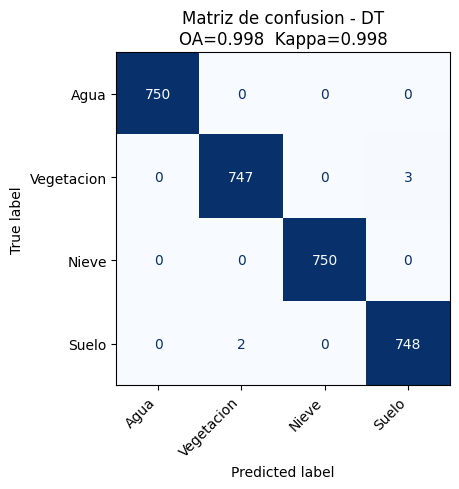


  --- SVM ---
      Overall Accuracy : 0.9950   Kappa : 0.9933   F1-macro : 0.9950
      Matriz de confusion (filas=real, cols=predicho):
            Agua  Vegetacion  Nieve  Suelo
Agua         750           0      0      0
Vegetacion     0         735      0     15
Nieve          0           0    750      0
Suelo          0           0      0    750
              precision    recall  f1-score   support

        Agua      1.000     1.000     1.000       750
  Vegetacion      1.000     0.980     0.990       750
       Nieve      1.000     1.000     1.000       750
       Suelo      0.980     1.000     0.990       750

    accuracy                          0.995      3000
   macro avg      0.995     0.995     0.995      3000
weighted avg      0.995     0.995     0.995      3000



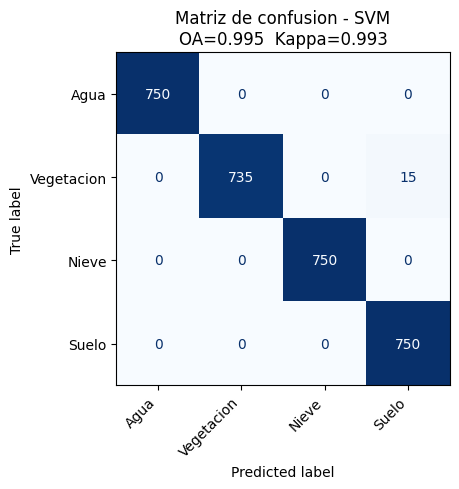


  --- ANN ---
      Overall Accuracy : 0.9993   Kappa : 0.9991   F1-macro : 0.9993
      Matriz de confusion (filas=real, cols=predicho):
            Agua  Vegetacion  Nieve  Suelo
Agua         750           0      0      0
Vegetacion     0         748      0      2
Nieve          0           0    750      0
Suelo          0           0      0    750
              precision    recall  f1-score   support

        Agua      1.000     1.000     1.000       750
  Vegetacion      1.000     0.997     0.999       750
       Nieve      1.000     1.000     1.000       750
       Suelo      0.997     1.000     0.999       750

    accuracy                          0.999      3000
   macro avg      0.999     0.999     0.999      3000
weighted avg      0.999     0.999     0.999      3000



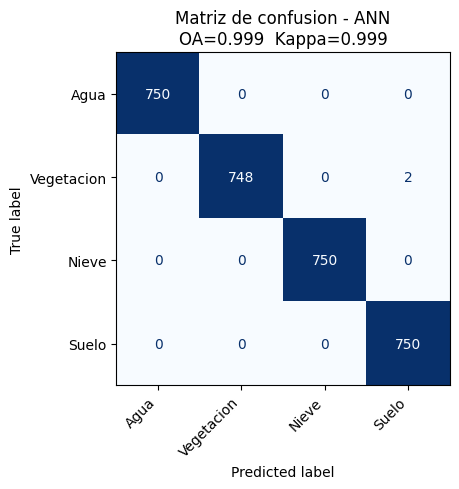


  --- KNN ---
      Overall Accuracy : 0.9973   Kappa : 0.9964   F1-macro : 0.9973
      Matriz de confusion (filas=real, cols=predicho):
            Agua  Vegetacion  Nieve  Suelo
Agua         750           0      0      0
Vegetacion     0         742      0      8
Nieve          0           0    750      0
Suelo          0           0      0    750
              precision    recall  f1-score   support

        Agua      1.000     1.000     1.000       750
  Vegetacion      1.000     0.989     0.995       750
       Nieve      1.000     1.000     1.000       750
       Suelo      0.989     1.000     0.995       750

    accuracy                          0.997      3000
   macro avg      0.997     0.997     0.997      3000
weighted avg      0.997     0.997     0.997      3000



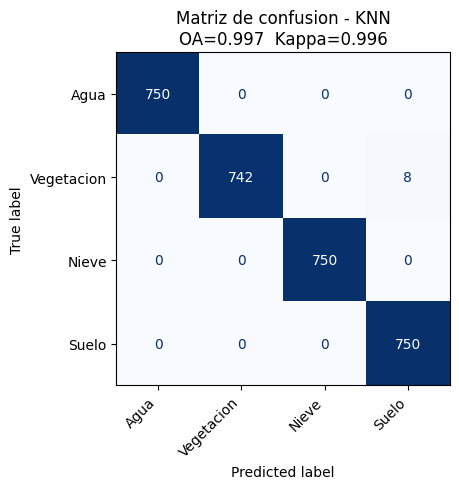


  --- NB ---
      Overall Accuracy : 0.9917   Kappa : 0.9889   F1-macro : 0.9917
      Matriz de confusion (filas=real, cols=predicho):
            Agua  Vegetacion  Nieve  Suelo
Agua         750           0      0      0
Vegetacion     0         731      0     19
Nieve          0           0    750      0
Suelo          0           5      1    744
              precision    recall  f1-score   support

        Agua      1.000     1.000     1.000       750
  Vegetacion      0.993     0.975     0.984       750
       Nieve      0.999     1.000     0.999       750
       Suelo      0.975     0.992     0.983       750

    accuracy                          0.992      3000
   macro avg      0.992     0.992     0.992      3000
weighted avg      0.992     0.992     0.992      3000



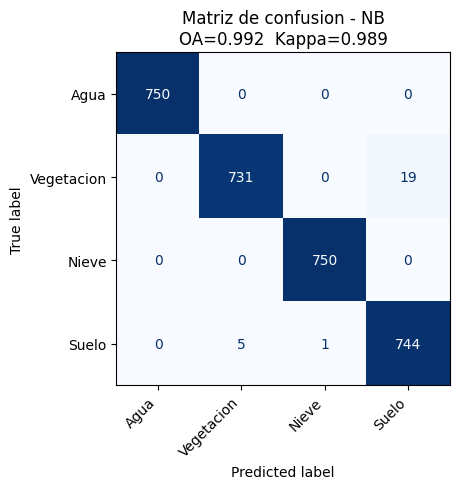


[4/4] Resumen comparativo (linea base, sin HPO):
Modelo     OA  Kappa  F1_macro
   ANN 0.9993 0.9991    0.9993
    DT 0.9983 0.9978    0.9983
   KNN 0.9973 0.9964    0.9973
   SVM 0.9950 0.9933    0.9950
    NB 0.9917 0.9889    0.9917

Productos guardados en: /content/drive/MyDrive/TDE4_Fase2/fase2_salidas


,Modelo,OA,Kappa,F1_macro
0,ANN,0.999333,0.999111,0.999333
1,DT,0.998333,0.997778,0.998333
2,KNN,0.997333,0.996444,0.997333
3,SVM,0.995000,0.993333,0.994999
4,NB,0.991667,0.988889,0.991665


In [20]:
stack_path = build_stack()
df = build_tsv(stack_path)
summary = train_and_evaluate(df)
summary
